In [2]:
from idlelib import history

import keras
from lightgbm import early_stopping
from sklearn.model_selection import train_test_split

In [4]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [5]:
def model_fn(a_layer=None):
    import keras
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28,28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu'))

    if a_layer:
        model.add(a_layer)

    model.add(keras.layers.Dense(10, activation='softmax'))
    return model

In [7]:
model = model_fn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(train_scaled, train_target, epochs=5, verbose=0)

In [9]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

In [10]:
import matplotlib.pyplot as plt

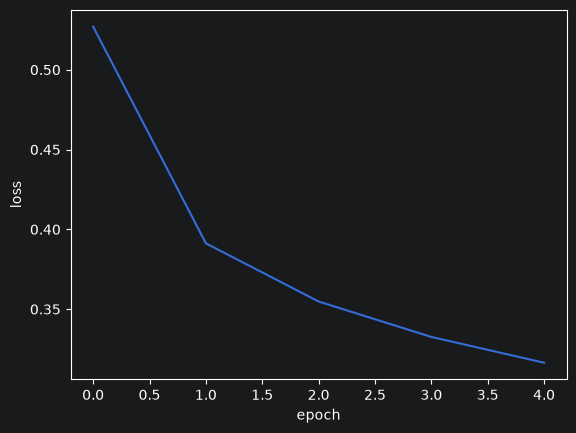

In [14]:
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

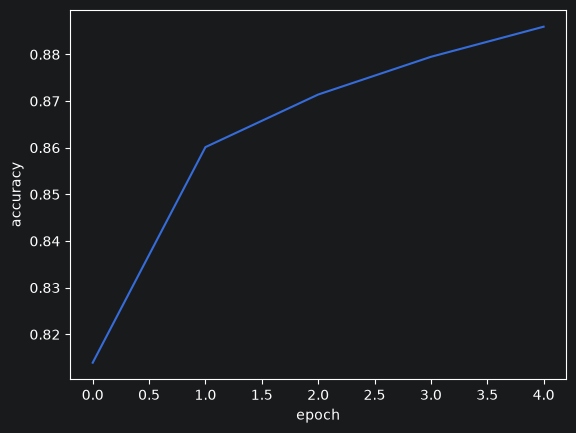

In [15]:
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

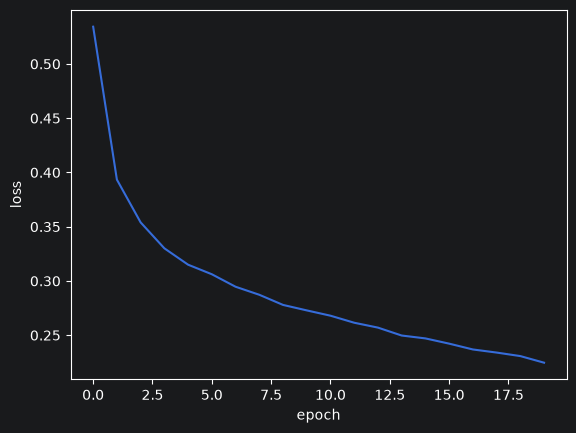

In [16]:
model = model_fn()
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(train_scaled, train_target, epochs=20, verbose=0)

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [17]:
model = model_fn()
model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(train_scaled, train_target,
                    epochs=20,
                    verbose=0,
                    validation_data=( val_scaled, val_target )
                    )

In [18]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

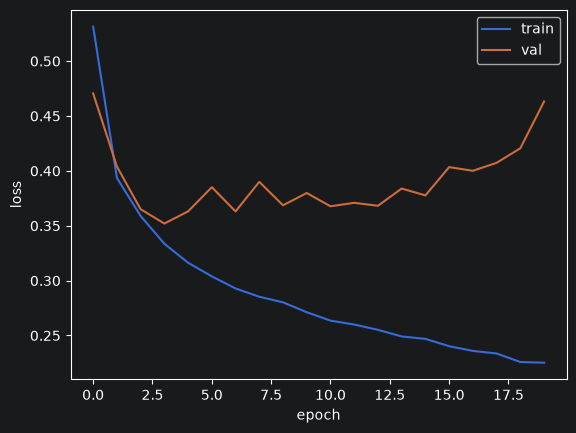

In [19]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


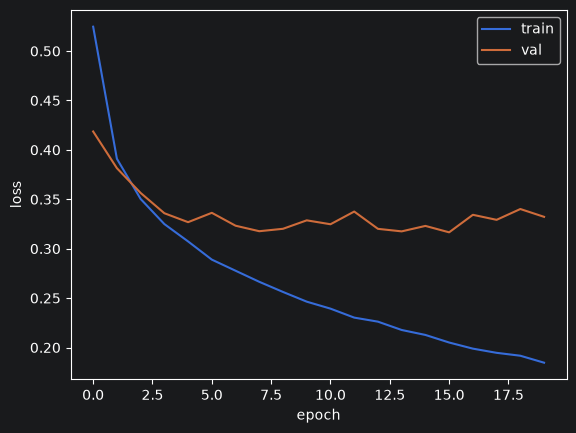

In [20]:
model = model_fn()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(train_scaled, train_target,
                    epochs=20,
                    verbose=0,
                    validation_data=( val_scaled, val_target )
                    )

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


In [21]:
model = model_fn(keras.layers.Dropout(0.3))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

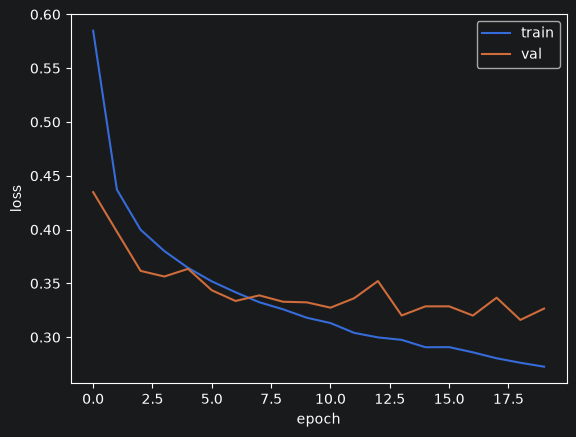

In [22]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(train_scaled, train_target,
                    epochs=20,
                    verbose=0,
                    validation_data=( val_scaled, val_target )
                    )

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()


In [23]:
model.summary()
model = model_fn(keras.layers.Dropout(0.3))
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history = model.fit(train_scaled, train_target,
                    epochs=13,
                    verbose=0,
                    validation_data=(val_scaled, val_target)
                    )

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [27]:
model.save('./modelFile/model-whole.keras')
model.save_weights('./modelFile/model-whole.weights.h5')

In [28]:
model = model_fn(keras.layers.Dropout(0.3))
model.load_weights('./modelFile/model-whole.weights.h5')

In [29]:
import numpy as np

In [30]:
val_labels = np.argmax(model.predict(val_scaled), axis=-1)
print(np.mean(val_labels == val_target))

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step
0.8820833333333333


In [31]:
model = keras.models.load_model('../modelFile/model-whole.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - accuracy: 0.8821 - loss: 0.3246  


[0.324604868888855, 0.8820833563804626]

In [32]:
model = model_fn(keras.layers.Dropout(0.3))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../modelFile/best-model.keras', save_best_only=True)

model.fit(train_scaled, train_target,
            epochs=20,
            verbose=1,
            validation_data=(val_scaled, val_target),
            callbacks=[checkpoint_cb]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.7932 - loss: 0.5917 - val_accuracy: 0.8401 - val_loss: 0.4322
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - accuracy: 0.8425 - loss: 0.4384 - val_accuracy: 0.8544 - val_loss: 0.3881
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 873us/step - accuracy: 0.8536 - loss: 0.4039 - val_accuracy: 0.8618 - val_loss: 0.3730
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 878us/step - accuracy: 0.8606 - loss: 0.3805 - val_accuracy: 0.8695 - val_loss: 0.3570
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8641 - loss: 0.3690 - val_accuracy: 0.8758 - val_loss: 0.3408
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8693 - loss: 0.3533 - val_accuracy: 0.8745 - val_loss: 0.3436
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - accuracy: 0.8720 - loss: 0.3465 - val_accuracy: 0.8784 - val_loss: 0.3324
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - accuracy: 0.8775 - los

In [33]:
model = keras.models.load_model('../modelFile/best-model.keras')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 621us/step - accuracy: 0.8862 - loss: 0.3115  


[0.3114716410636902, 0.8861666917800903]

In [38]:
model = model_fn(keras.layers.Dropout(0.3))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

checkpoint_cb = keras.callbacks.ModelCheckpoint('../modelFile/best-model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

history = model.fit(train_scaled, train_target,
            epochs=20,
            verbose=0,
            validation_data=(val_scaled, val_target),
            callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7934 - loss: 0.5863 - val_accuracy: 0.8432 - val_loss: 0.4410
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8440 - loss: 0.4359 - val_accuracy: 0.8628 - val_loss: 0.3777
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - accuracy: 0.8548 - loss: 0.4012 - val_accuracy: 0.8712 - val_loss: 0.3636
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 840us/step - accuracy: 0.8615 - loss: 0.3803 - val_accuracy: 0.8727 - val_loss: 0.3489
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8674 - loss: 0.3622 - val_accuracy: 0.8748 - val_loss: 0.3377
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.8705 - loss: 0.3490 - val_accuracy: 0.8751 - val_loss: 0.3472
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8755 - loss: 0.3371 - val_accuracy: 0.8768 - val_loss: 0.3372
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.8798 - loss: 0

In [39]:
print(early_stopping_cb.stopped_epoch)

12


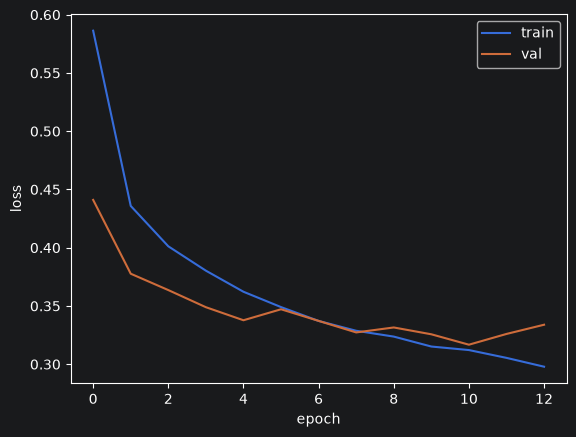

In [40]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [41]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.8850 - loss: 0.3167


[0.31674036383628845, 0.8849999904632568]